# Week 1 — Transfer Learning with ResNet-18

**Author:** Holly &nbsp;·&nbsp; **Subteam:** AI / ML &nbsp;·&nbsp; **Branch:** `homework/ml-ai/holly/transfer-learning`

Sortify has to sort a photo of a piece of waste into one of five bins. Training a
ConvNet for that from scratch would need far more labelled images than we have,
so instead we start from a **ResNet-18 already trained on ImageNet** and reuse
its visual features. This is the same pipeline the real Sortify classifier will
use — only the size of the dataset changes.

Reference: [PyTorch Transfer Learning Tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

### What this notebook does

| Step | Action |
| --- | --- |
| 1 | Check the environment and pick a device (CUDA / MPS / CPU) |
| 2 | Pull a 50-image sample of real waste photos and load it with `ImageFolder` |
| 3 | Load a pretrained ResNet-18 from `torchvision.models` |
| 4 | Freeze the backbone (`requires_grad = False`) |
| 5 | Replace `model.fc` so it outputs **5** classes instead of 1000 |
| 6 | Train for 2 epochs with `CrossEntropyLoss` + `Adam` |
| 7 | Run inference on one held-out image and print class + confidence |

### Why freeze the backbone?

ResNet-18's convolutional layers already detect edges, textures and materials which are generic features that transfer to waste photos. Only the final classification
layer is ImageNet-specific, so we only need to train this again. 

---
## Step 1 — Environment and device

In [1]:
import sys
from pathlib import Path

import torch
import torchvision
from PIL import Image
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

print(f"Python       : {sys.version.split()[0]}")
print(f"torch        : {torch.__version__}")
print(f"torchvision  : {torchvision.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"MPS available  : {torch.backends.mps.is_available()}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"\nUsing device: {device}")

Python       : 3.11.9
torch        : 2.14.0+cpu
torchvision  : 0.29.0+cpu
CUDA available : False
MPS available  : False

Using device: cpu


---
## Step 2 — Real waste photos from Hugging Face

The images come from
[`rootstrap-org/waste-classifier`](https://huggingface.co/datasets/rootstrap-org/waste-classifier).
It has 7 labels; we use the **5** that map onto Sortify's bins and drop
`cardboard` and `metal`. `download_waste_sample.py` (next to this notebook) pulls **10 train + 5 val
images per label** (50 training images).

In [2]:
# The notebook sits next to download_waste_sample.py, so import it directly.
sys.path.insert(0, str(Path.cwd()))
from download_waste_sample import DEFAULT_OUT_DIR, WANTED_LABELS, download_sample

DATA_DIR = DEFAULT_OUT_DIR
TRAIN_PER_CLASS = 10  # 5 labels x 10 = the 50-image training set
VAL_PER_CLASS = 5
SEED = 42

torch.manual_seed(SEED)

if not DATA_DIR.is_dir():
    download_sample(
        per_class=TRAIN_PER_CLASS,
        val_per_class=VAL_PER_CLASS,
        seed=SEED,
    )
else:
    print(f"Using existing sample at {DATA_DIR}")

print(f"Labels: {WANTED_LABELS}")

Using existing sample at C:\Users\holly\Documents\Documents\UCB\Sortify\Sortify\transfer_learning_tutorial\data\waste_sample
Labels: ['compost', 'glass', 'paper', 'plastic', 'trash']


### Preprocessing and the DataLoaders

Pretrained weights would expect their original preprocessing: resize, crop to
224x224, then normalise with the **ImageNet** channel mean and standard
deviation.

Transformations for training data is random whereas those for validation data is deterministic (as Val should look like inference).

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_transforms = {
    "train": transforms.Compose(
        [
            transforms.RandomResizedCrop(224, scale=(0.7, 1.0)), # make the input legal
            transforms.RandomHorizontalFlip(), # ensure model learn that bottle img flipped is still a bottle
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    ),
    "val": transforms.Compose(
        [
            transforms.Resize(256), # make the input legal 
            transforms.CenterCrop(224), # make the input legal
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    ),
}

image_datasets = {
    split: datasets.ImageFolder(DATA_DIR / split, data_transforms[split])
    for split in ["train", "val"]
}
dataloaders = {
    "train": DataLoader(image_datasets["train"], batch_size=8, shuffle=True),
    "val": DataLoader(image_datasets["val"], batch_size=8),
}
dataset_sizes = {split: len(image_datasets[split]) for split in ["train", "val"]}
class_names = image_datasets["train"].classes
NUM_CLASSES = len(class_names)

print(f"Classes (ImageFolder sorts alphabetically): {class_names}")
print(f"Label mapping : {image_datasets['train'].class_to_idx}")
print(f"Sizes : {dataset_sizes}")
print(f"Batches / epoch : {len(dataloaders['train'])} at batch_size=8")

Classes (ImageFolder sorts alphabetically): ['compost', 'glass', 'paper', 'plastic', 'trash']
Label mapping : {'compost': 0, 'glass': 1, 'paper': 2, 'plastic': 3, 'trash': 4}
Sizes : {'train': 50, 'val': 25}
Batches / epoch : 7 at batch_size=8


---
## Step 3 — Load the pretrained ResNet-18

In [ ]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

total_params = sum(p.numel() for p in model.parameters()) # .numel = number of elements in the tensor
print(f"Weights : {weights}")
print(f"Total parameters : {total_params:,}")
print(f"Original head    : {model.fc}")

Weights : ResNet18_Weights.IMAGENET1K_V1
Total parameters : 11,689,512
Original head    : Linear(in_features=512, out_features=1000, bias=True)


---
## Step 4 — Freeze the backbone

Setting `requires_grad = False` on every parameter tells autograd not to compute
gradients for them, so the optimizer cannot change them. The ImageNet features
stay exactly as they are and the backward pass gets much cheaper.

In [6]:
for param in model.parameters():
    param.requires_grad = False

frozen_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters after freezing: {frozen_trainable:,}")

Trainable parameters after freezing: 0


---
## Step 5 — Replace the classification head

The pretrained `fc` maps 512 features to ImageNet's 1000 categories. We swap it
for a fresh `nn.Linear(512, 5)`.

Order matters: a newly constructed layer defaults to `requires_grad = True`, so
replacing `fc` **after** the freeze leaves the new head as the only trainable
part of the network.

In [7]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"New head : {model.fc}")
print(f"Trainable parameters : {trainable:,} of {total_params:,}")
print(f"  = {num_features} features x {NUM_CLASSES} classes + {NUM_CLASSES} biases")
print(f"  = {trainable / total_params:.4%} of the network")

New head : Linear(in_features=512, out_features=5, bias=True)
Trainable parameters : 2,565 of 11,689,512
  = 512 features x 5 classes + 5 biases
  = 0.0219% of the network


---
## Step 6 — Train for 2 epochs

`CrossEntropyLoss` takes raw logits (applies `log_softmax` internally), and `Adam` receives **only**
`model.fc.parameters()`. Handing it `model.parameters()` would still work,
because the frozen tensors have no gradients, but passing just the head makes
the intent explicit and keeps the optimizer state small.

Each epoch runs a training pass and then a validation pass on images the model
never trains on.

In [8]:
EPOCHS = 2
LEARNING_RATE = 5e-3  # 2 epochs over 50 images is only 14 gradient steps

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

history = []
for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    print("-" * 10)
    epoch_stats = {}

    for phase in ["train", "val"]:
        if phase == "train":
            model.train()
            # Frozen backbone => keep BatchNorm on its pretrained running stats.
            for module in model.modules():
                if isinstance(module, nn.BatchNorm2d):
                    module.eval()
        else:
            model.eval()

        running_loss = 0.0
        running_correct = 0

        for step, (images, labels) in enumerate(dataloaders[phase], start=1):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == "train"):
                outputs = model(images)
                loss = criterion(outputs, labels)
                if phase == "train":
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * images.size(0)
            running_correct += (outputs.argmax(dim=1) == labels).sum().item()
            if phase == "train":
                print(
                    f"  step {step}/{len(dataloaders[phase])}  loss {loss.item():.4f}"
                )

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_correct / dataset_sizes[phase]
        epoch_stats[phase] = (epoch_loss, epoch_acc)
        print(f"  {phase:<5} loss {epoch_loss:.4f}  acc {epoch_acc:.2%}")

    history.append(epoch_stats)
    print()

print("Summary")
for phase in ["train", "val"]:
    losses = "  ->  ".join(f"{h[phase][0]:.4f}" for h in history)
    accs = "  ->  ".join(f"{h[phase][1]:.0%}" for h in history)
    print(f"  {phase:<5} loss {losses}   acc {accs}")

Epoch 1/2
----------


  step 1/7  loss 1.8095
  step 2/7  loss 1.4472


  step 3/7  loss 1.9333
  step 4/7  loss 0.8545


  step 5/7  loss 1.7591
  step 6/7  loss 0.7204


  step 7/7  loss 1.6207
  train loss 1.4287  acc 38.00%


  val   loss 1.4117  acc 48.00%

Epoch 2/2
----------
  step 1/7  loss 0.7174


  step 2/7  loss 1.4643
  step 3/7  loss 0.5240


  step 4/7  loss 1.3159
  step 5/7  loss 0.7974


  step 6/7  loss 0.1062
  step 7/7  loss 1.6391
  train loss 0.8536  acc 74.00%


  val   loss 0.8382  acc 72.00%

Summary
  train loss 1.4287  ->  0.8536   acc 38%  ->  74%
  val   loss 1.4117  ->  0.8382   acc 48%  ->  72%


---
## Step 7 — Inference on a single held-out image

In [9]:
model.eval()

# Pick the first validation image of a known class.
true_label = "plastic"
val_images = sorted((DATA_DIR / "val" / true_label).glob("*.jpg"))
test_image_path = val_images[0]

test_image = Image.open(test_image_path).convert("RGB")
input_tensor = data_transforms["val"](test_image).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)
    probabilities = torch.softmax(logits, dim=1)[0]

confidence, predicted_index = torch.max(probabilities, dim=0)
predicted_class = class_names[predicted_index]

print(f"Image           : {test_image_path.name}")
print(f"True class      : {true_label}")
print(f"Predicted class : {predicted_class}")
print(f"Confidence      : {confidence.item():.2%}")
print("\nFull probability distribution:")
for name, prob in zip(class_names, probabilities.tolist(), strict=True):
    bar = "#" * round(prob * 40)
    print(f"  {name:<9} {prob:.4f}  {bar}")

Image           : plastic_000.jpg
True class      : plastic
Predicted class : plastic
Confidence      : 77.74%

Full probability distribution:
  compost   0.0985  ####
  glass     0.0291  #
  paper     0.0732  ###
  plastic   0.7774  ###############################
  trash     0.0217  #


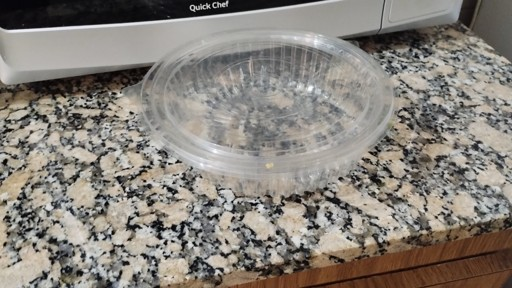

In [10]:
# The held-out image the prediction above was made on.
test_image